In [1]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

Using: cuda


In [2]:
class PINNs(nn.Module):

    NUM_NEUROS = 40
    NUM_LAYERS = 9

    def __init__(self):
        super().__init__()
        
        layers = []

        #first_layer
        layers.append(nn.Linear(2, self.NUM_NEUROS))
        layers.append(nn.Tanh())

        # black box of 8 layers
        for _ in range(self.NUM_LAYERS - 1):
            layers.append(nn.Linear(self.NUM_NEUROS, self.NUM_NEUROS))
            layers.append(nn.Tanh())

        layers.append(nn.Linear(self.NUM_NEUROS, 1))

        self.network = nn.Sequential(*layers)
        

    def forward(self, t, x):
        inputs = torch.cat([t, x], dim=1)
        return self.network(inputs)

In [3]:
model = PINNs()
t_test = torch.rand(5, 1)  # 5 random t values
x_test = torch.rand(5, 1)  # 5 random x values
u_pred = model(t_test, x_test)
print(u_pred.shape)  # should be torch.Size([5, 1])
print(u_pred)        # random numbers, network is untrained

torch.Size([5, 1])
tensor([[-0.1177],
        [-0.1174],
        [-0.1176],
        [-0.1178],
        [-0.1185]], grad_fn=<AddmmBackward0>)


In [4]:
def physics_part(model, t, x):

    """
        heat equation defined as u_t = alpha * u_xx
        simplicity alpha = 1
    """
    
    alpha = 1
    t = t.clone().detach().requires_grad_(True)
    x = x.clone().detach().requires_grad_(True)

    u = model(t, x)

    u_t = torch.autograd.grad(
        u, t, 
        grad_outputs=torch.ones_like(u),
        create_graph=True,
        retain_graph=True
    )[0]

    u_x = torch.autograd.grad(
        u, x, 
        grad_outputs=torch.ones_like(u), 
        create_graph=True,
        retain_graph=True
    )[0]

    u_xx = torch.autograd.grad(
        u_x, x, 
        grad_outputs=torch.ones_like(u), 
        create_graph=True,
        retain_graph=True
    )[0]

    f = u_t + u * u_x - (0.01/torch.pi)*u_xx

    return f

In [5]:
t_test = torch.rand(5, 1)
x_test = torch.rand(5, 1)
f = physics_part(model, t_test, x_test)
print(f.shape)  # should be (5, 1)
print(f)        # random values — residual is nonzero because network is untrained

torch.Size([5, 1])
tensor([[ 2.6699e-05],
        [-3.5634e-04],
        [-7.1143e-04],
        [-2.3251e-04],
        [-1.0347e-03]], grad_fn=<SubBackward0>)


In [6]:
# Number of points
N_ic = 100    # initial condition points
N_bc = 100    # boundary condition points (total, both sides)
N_f = 10000   # collocation points

# ---- Initial condition: t=0, x random in [-1,1] ----
t_ic = torch.zeros(N_ic, 1)
x_ic = 2 * torch.rand(N_ic, 1) - 1
u_ic = - torch.sin(torch.pi * x_ic)  # known values

# ---- Boundary conditions ----
# Left boundary: x=0, t random in [-1,1]
t_bc_left = torch.rand(N_bc // 2, 1)
x_bc_left = - torch.ones(N_bc // 2, 1)
u_bc_left = torch.zeros(N_bc // 2, 1)

# Right boundary: x=1, t random in [0,1]
t_bc_right = torch.rand(N_bc // 2, 1)
x_bc_right = torch.ones(N_bc // 2, 1)
u_bc_right = torch.zeros(N_bc // 2, 1)

# Combine all boundary/initial data
t_data = torch.cat([t_ic, t_bc_left, t_bc_right]).to(device)
x_data = torch.cat([x_ic, x_bc_left, x_bc_right]).to(device)
u_data = torch.cat([u_ic, u_bc_left, u_bc_right]).to(device)

# ---- Collocation points: random in interior ----
t_f = torch.rand(N_f, 1).to(device)
x_f = (2 * torch.rand(N_f, 1) - 1).to(device)

In [7]:
print(f"Data points: {t_data.shape[0]}")
print(f"Collocation points: {t_f.shape[0]}")
print(f"Sample initial condition: t={t_ic[0].item():.1f}, x={x_ic[0].item():.3f}, u={u_ic[0].item():.3f}")


Data points: 200
Collocation points: 10000
Sample initial condition: t=0.0, x=0.060, u=-0.186


In [8]:
def compute_loss(model, t_data, x_data, u_data, t_f, x_f):
    u_pred = model(t_data, x_data)
    mse_u = torch.mean((u_pred - u_data)**2)
    
    f = physics_part(model=model, t=t_f, x=x_f)
    mse_f = torch.mean(f ** 2)

    total_loss = mse_u + mse_f

    return total_loss, mse_u, mse_f

In [ ]:
# training loop 

model = PINNs().to(device)
optimzer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epocs = 5000
for epoch in range(num_epocs):
    optimzer.zero_grad()

    loss, mse_u, mse_f = compute_loss(
        model=model, 
        t_data= t_data, x_data= x_data,
        u_data=u_data, x_f=x_f, t_f=t_f
    )

    loss.backward()
    optimzer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch:5d} | Loss: {loss.item():.6f} | "
                f"MSE_u: {mse_u.item():.6f} | MSE_f: {mse_f.item():.6f}")
        
#paper replication has 2 phase training, 2nd with l-bfgs
optimzer_lbfgs = torch.optim.LBFGS(
    model.parameters(),
    lr=1,
    max_iter=50000,
    max_eval=50000,
    tolerance_grad=1e-7,
    tolerance_change=1e-9,
    history_size=50,
    line_search_fn="strong_wolfe"
)

iteration = [0]
def closure():
    optimzer_lbfgs.zero_grad()
    loss, mse_u, mse_f = compute_loss(
        model , 
        t_data= t_data, x_data= x_data,
        u_data=u_data, x_f=x_f, t_f=t_f
    )
    loss.backward()

    iteration[0] += 1
    if iteration[0] % 500 == 0:
        print(f"L-BFGS iter {iteration[0]:5d} | Loss: {loss.item():.6f} | "
              f"MSE_u: {mse_u.item():.6f} | MSE_f: {mse_f.item():.6f}")

    return loss

optimzer_lbfgs.step(closure=closure)

/mnt/d/repos/Physics-informed-Neural-Networks/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch     0 | Loss: 0.228126 | MSE_u: 0.228125 | MSE_f: 0.000001
Epoch   500 | Loss: 0.032064 | MSE_u: 0.022036 | MSE_f: 0.010028
Epoch  1000 | Loss: 0.012158 | MSE_u: 0.005209 | MSE_f: 0.006949


In [ ]:
import numpy as np
from scipy.integrate import quad

def exact_burgers(t_val, x_val, nu=0.01/np.pi, n_terms=100):
    if t_val == 0:
        return -np.sin(np.pi * x_val)
    
    def phi(xi):
        return np.exp(-np.cos(np.pi * xi) / (2 * np.pi * nu))
    
    def integrand_num(xi):
        return np.sin(np.pi * xi) * phi(xi) * np.exp(
            -(x_val - xi)**2 / (4 * nu * t_val)
        )
    
    def integrand_den(xi):
        return phi(xi) * np.exp(
            -(x_val - xi)**2 / (4 * nu * t_val)
        )
    
    num, _ = quad(integrand_num, -1, 1)
    den, _ = quad(integrand_den, -1, 1)
    
    return -num / (den + 1e-30)

Computing exact solution...
Done.


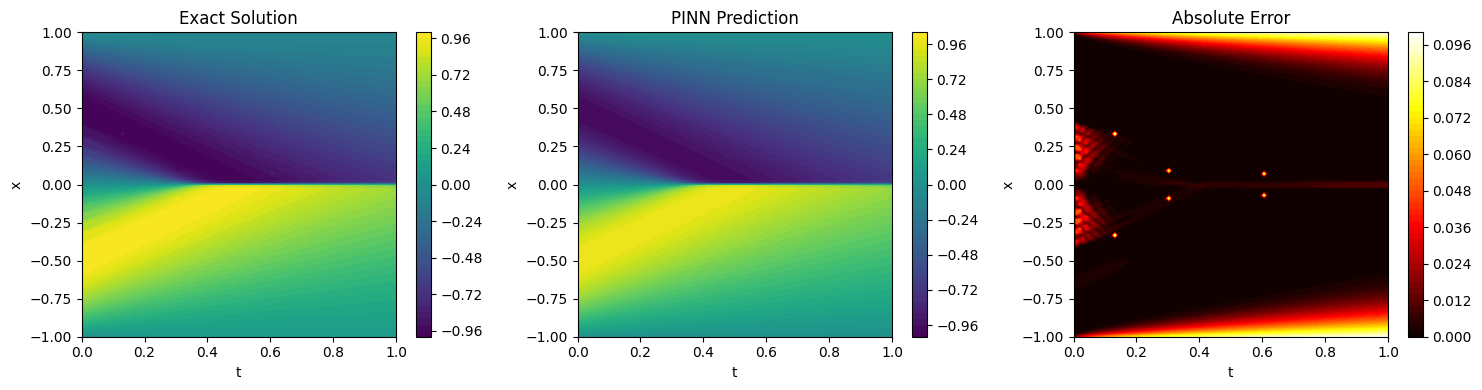

Max error: 0.098488
first error 0.032683 - heat with bad learning rate
second error 0.045695- heat with okay learning rate


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create a grid
t_grid = np.linspace(0, 1, 100)
x_grid = np.linspace(-1, 1, 100)
T, X = np.meshgrid(t_grid, x_grid)

# Convert to tensors
t_flat = torch.tensor(T.flatten(), dtype=torch.float32).unsqueeze(1).to(device)
x_flat = torch.tensor(X.flatten(), dtype=torch.float32).unsqueeze(1).to(device)

# PINN prediction
with torch.no_grad():
    u_pred = model(t_flat, x_flat).cpu().numpy().reshape(100, 100)

# Exact solution
print("Computing exact solution...")
u_exact = np.zeros_like(T)
for i in range(T.shape[0]):
    for j in range(T.shape[1]):
        u_exact[i, j] = exact_burgers(T[i, j], X[i, j])
print("Done.")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
c = ax.contourf(T, X, u_exact, levels=50, cmap='viridis')
ax.set_title('Exact Solution')
ax.set_xlabel('t')
ax.set_ylabel('x')
plt.colorbar(c, ax=ax)

ax = axes[1]
c = ax.contourf(T, X, u_pred, levels=50, cmap='viridis')
ax.set_title('PINN Prediction')
ax.set_xlabel('t')
ax.set_ylabel('x')
plt.colorbar(c, ax=ax)

ax = axes[2]
c = ax.contourf(T, X, np.abs(u_exact - u_pred), levels=50, cmap='hot')
ax.set_title('Absolute Error')
ax.set_xlabel('t')
ax.set_ylabel('x')
plt.colorbar(c, ax=ax)

plt.tight_layout()
plt.savefig('pinn_heat_equation.png', dpi=150)
plt.show()
print(f"Max error: {np.max(np.abs(u_exact - u_pred)):.6f}")

print('first error 0.032683 - heat with bad learning rate')
print('second error 0.045695- heat with okay learning rate')